In [129]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set paths
dataset_folder = 'Dataset/'
normal_folder = 'Dataset/NormalClass/'

# # Extract all zipped files from attacks
# print("Extracting attack dataset files...")
# for file in os.listdir(dataset_folder):
#     if file.endswith('.zip') and 'NormalClass' not in file:
#         zip_path = os.path.join(dataset_folder, file)
#         with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#             zip_ref.extractall(dataset_folder)
#         print(f"Extracted {file}")

# # Extract all zipped files from normal class
# print("\nExtracting normal class dataset files...")
# if os.path.exists(normal_folder):
#     for file in os.listdir(normal_folder):
#         if file.endswith('.zip'):
#             zip_path = os.path.join(normal_folder, file)
#             with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#                 zip_ref.extractall(normal_folder)
#             print(f"Extracted {file}")



## 2. Load Datasets

In [130]:
# Load all attack CSVs
print("Loading attack datasets...")
dfs = []

for file in sorted(os.listdir(dataset_folder)):
    if file.endswith('.csv') and 'NormalClass' not in file:
        file_path = os.path.join(dataset_folder, file)
        try:
      
            attack_type = file.replace('.csv', '').replace('_attack', '').replace('DDoS_', 'DDoS_')
            
            df_temp = pd.read_csv(file_path)
            
         
            df_temp = df_temp.head(10000)
            if 'frame.time' in df_temp.columns:
                df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                df_temp = df_temp.dropna(subset=['frame.time'])
                
                # remove invalid years
                df_temp = df_temp[
                    (df_temp['frame.time'].dt.year >= 2000) &
                    (df_temp['frame.time'].dt.year <= 2030)
                ]

   
            df_temp = df_temp.head(10000)

          
            if 'Attack_type' not in df_temp.columns:
                df_temp['Attack_type'] = attack_type
            
            
            # Sort by IP and time
            if 'ip.dst_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                df_temp = df_temp.sort_values(['ip.dst_host', 'frame.time']).reset_index(drop=True)
            
            dfs.append(df_temp)
            print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
        except Exception as e:
            print(f"  ✗ {file:40s} - Error: {str(e)}")


print("\nLoading normal class datasets...")
normal_folder = 'Dataset/NormalClass/'
if os.path.exists(normal_folder):
    normal_dfs = []
    for file in sorted(os.listdir(normal_folder)):
        if file.endswith('.csv'):
            file_path = os.path.join(normal_folder, file)
            try:
                df_temp = pd.read_csv(file_path)
                
                # Get a portion of normal data (enough to reach 10,000 total across all normal files)
                df_temp = df_temp.head(10000)  
                
                # Add attack type as 'Normal'
                df_temp['Attack_type'] = 'Normal'
                
                # Ensure frame.time is parsed as datetime
                if 'frame.time' in df_temp.columns:
                    df_temp['frame.time'] = pd.to_datetime(df_temp['frame.time'], errors='coerce')
                
                # Sort by IP and time
                if 'ip.dst_host' in df_temp.columns and 'frame.time' in df_temp.columns:
                    df_temp = df_temp.sort_values(['ip.dst_host', 'frame.time']).reset_index(drop=True)
                
                normal_dfs.append(df_temp)
                print(f"  ✓ {file:40s} - {len(df_temp):6d} rows")
            except Exception as e:
                print(f"  ✗ {file:40s} - Error: {str(e)}")
    
    if normal_dfs:
        df_normal = pd.concat(normal_dfs, axis=0, ignore_index=True).head(5000)
        dfs.append(df_normal)
        print(f"\n  ✓ Normal class combined - {len(df_normal):6d} rows (total from {len(normal_dfs)} files)")

print(f"\nCombining {len(dfs)} datasets into one sorted time series...")
df_combined = pd.concat(dfs, axis=0, ignore_index=True)

# Final sort by IP and time
if 'ip.dst_host' in df_combined.columns and 'frame.time' in df_combined.columns:
    df_combined = df_combined.sort_values(['ip.dst_host', 'frame.time']).reset_index(drop=True)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"\nAttack types in dataset:")
print(df_combined['Attack_type'].value_counts())

Loading attack datasets...
  ✓ Backdoor_attack.csv                      -  10000 rows
  ✓ DDoS_HTTP_Flood_attack.csv               -  10000 rows
  ✓ DDoS_ICMP_Flood_attack.csv               -  10000 rows
  ✓ DDoS_TCP_SYN_Flood_attack.csv            -  10000 rows
  ✓ DDoS_UDP_Flood_attack.csv                -      0 rows
  ✓ MITM_attack.csv                          -      0 rows
  ✓ OS_Fingerprinting_attack.csv             -   1001 rows
  ✓ Password_attack.csv                      -  10000 rows
  ✓ Port_Scanning_attack.csv                 -  10000 rows
  ✓ Ransomware_attack.csv                    -  10000 rows
  ✓ SQL_injection_attack.csv                 -  10000 rows
  ✓ Uploading_attack.csv                     -  10000 rows
  ✓ Vulnerability_scanner_attack.csv         -  10000 rows
  ✓ XSS_attack.csv                           -  10000 rows

Loading normal class datasets...
  ✓ Distance.csv                             -  10000 rows
  ✓ Flame_Sensor.csv                         -  10000 

## 3. Data Preprocessing

In [131]:
df_bck=df_combined.copy()  # Backup before dropping duplicates
df_combined.drop_duplicates(subset=None, keep='first', inplace=True)

drop_columns = [
    'ip.src_host', 'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.file_data', 'http.request.full_uri', 'icmp.transmit_timestamp',
    'http.request.uri.query', 'tcp.options', 'tcp.payload', 'mqtt.msg', 'http.referer', 'http.request.version', 'tcp.srcport', 'dns.qry.name', 'mqtt.topic', 'mqtt.protoname',


]


drop_columns = [col for col in drop_columns if col in df_combined.columns]
df_combined.drop(columns=drop_columns, inplace=True)

# print(f"Dropped columns: {len(drop_columns)}")

In [132]:
df_combined.columns

Index(['frame.time', 'ip.dst_host', 'arp.opcode', 'arp.hw.size',
       'icmp.checksum', 'icmp.seq_le', 'icmp.unused', 'http.content_length',
       'http.request.method', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.seq',
       'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name.len',
       'dns.qry.qu', 'dns.qry.type', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags',
       'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msgtype',
       'mqtt.proto_len', 'mqtt.topic_len', 'mqtt.ver', 'mbtcp.len',
       'mbtcp.trans_id', 'mbtcp.unit_id', 'Attack_label', 'Attack_type'],
      dtype='str')

In [133]:
numeric_cols = [
    'icmp.seq_le',
    'tcp.ack_raw',
    'tcp.connection.fin',
    'tcp.len',
    'tcp.dstport',
    "arp.hw.size",
    # "udp.port",
    "tcp.ack_raw",
    # "mqtt.conack.flags",
"mqtt.conflags" ,
"mqtt.hdrflags",
    'tcp.flags',
    "icmp.checksum",
  "tcp.checksum"

]

def convert_mixed(val):
    if isinstance(val, str):
        val = val.strip()
        if val.startswith("0x"):  # hex value
            return int(val, 16)
        else:
            return pd.to_numeric(val, errors='coerce')
    return val  # already numeric

for col in numeric_cols:
    df_combined[col] = df_combined[col].apply(convert_mixed)



# # Drop rows where ANY of these columns is not numeric
# df_combined = df_combined.dropna(subset=numeric_cols)

In [134]:

single_value_cols = []
for col in df_combined.columns:
    if df_combined[col].nunique() == 1 and col not in ['Attack_type', 'Attack_label']:
        single_value_cols.append(col)

if single_value_cols:
    df_combined.drop(columns=single_value_cols, inplace=True)
    print(f"Dropped {len(single_value_cols)} single-value columns")
else:
    print("No single-value columns found")

Dropped 15 single-value columns


In [135]:
# Identify categorical and numerical columns
print("\nIdentifying column types...")
categorical_cols = df_combined.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_combined.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove columns that shouldn't be encoded
if 'frame.time' in categorical_cols:
    categorical_cols.remove('frame.time')
if 'ip.dst_host' in categorical_cols:
    categorical_cols.remove('ip.dst_host')
if 'Attack_type' in categorical_cols:
    categorical_cols.remove('Attack_type')
if 'Attack_label' in categorical_cols:
    categorical_cols.remove('Attack_label')

print(f"Categorical columns: {len(categorical_cols)}")
for col in categorical_cols[:5]:  # Show first 5
    print(f"  • {col}: {df_combined[col].nunique()} unique values")


Identifying column types...
Categorical columns: 2
  • http.request.method: 9 unique values
  • mqtt.conack.flags: 3 unique values


In [136]:
# One-hot encode categorical columns
for col in categorical_cols:
    dummies = pd.get_dummies(df_combined[col], prefix=col)
    df_combined = pd.concat([df_combined, dummies], axis=1)
    df_combined.drop(col, axis=1, inplace=True)
    print(f"   Encoded: {col}")

print(f"\nTotal columns after encoding: {df_combined.shape[1]}")

   Encoded: http.request.method
   Encoded: mqtt.conack.flags

Total columns after encoding: 42


In [137]:
# Sort by source IP and time (for time series)
print("Sorting data by IP and time...")
df_combined['frame.time'] = pd.to_datetime(df_combined['frame.time'], errors='coerce')
df_combined = df_combined.sort_values(['ip.dst_host', 'frame.time']).reset_index(drop=True)

print(f"Dataset shape: {df_combined.shape}")
print(f"Date range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")

Sorting data by IP and time...


Dataset shape: (116001, 42)
Date range: 2021-01-01 00:00:01.163427 to 2021-01-01 23:59:59.358821


In [138]:
# Define feature columns (exclude temporal and meta columns)
exclude_cols = ['frame.time', 'ip.dst_host', 'Attack_type', 'Attack_label']
feature_cols = [col for col in df_combined.columns if col not in exclude_cols]

print(f"Feature columns for scaling: {len(feature_cols)}")
print(f"\nFirst 10 feature columns:")
for col in feature_cols[:10]:
    print(f"  • {col}")

Feature columns for scaling: 38

First 10 feature columns:
  • arp.opcode
  • arp.hw.size
  • icmp.checksum
  • icmp.seq_le
  • http.content_length
  • http.response
  • tcp.ack
  • tcp.ack_raw
  • tcp.checksum
  • tcp.connection.fin


In [139]:
# Scale features using both StandardScaler and MinMaxScaler
print("Scaling features...\n")
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_features = df_combined[feature_cols].astype('float32')

# ===== StandardScaler (Z-score normalization) =====
print("1. StandardScaler (Z-score normalization):")
scaler_standard = StandardScaler()
df_features_standard = scaler_standard.fit_transform(df_features)
print(f"   Mean: {df_features_standard.mean():.6f}, Std: {df_features_standard.std():.6f}")

# Create scaled dataframe - StandardScaler
df_scaled = pd.DataFrame(df_features_standard, columns=feature_cols)
df_scaled['ip.dst_host'] = df_combined['ip.dst_host'].values
df_scaled['frame.time'] = df_combined['frame.time'].values
df_scaled['Attack_type'] = df_combined['Attack_type'].values
scaler = scaler_standard

Scaling features...

1. StandardScaler (Z-score normalization):
   Mean: 0.000000, Std: 1.000000


=== Scaling Methods Comparison ===



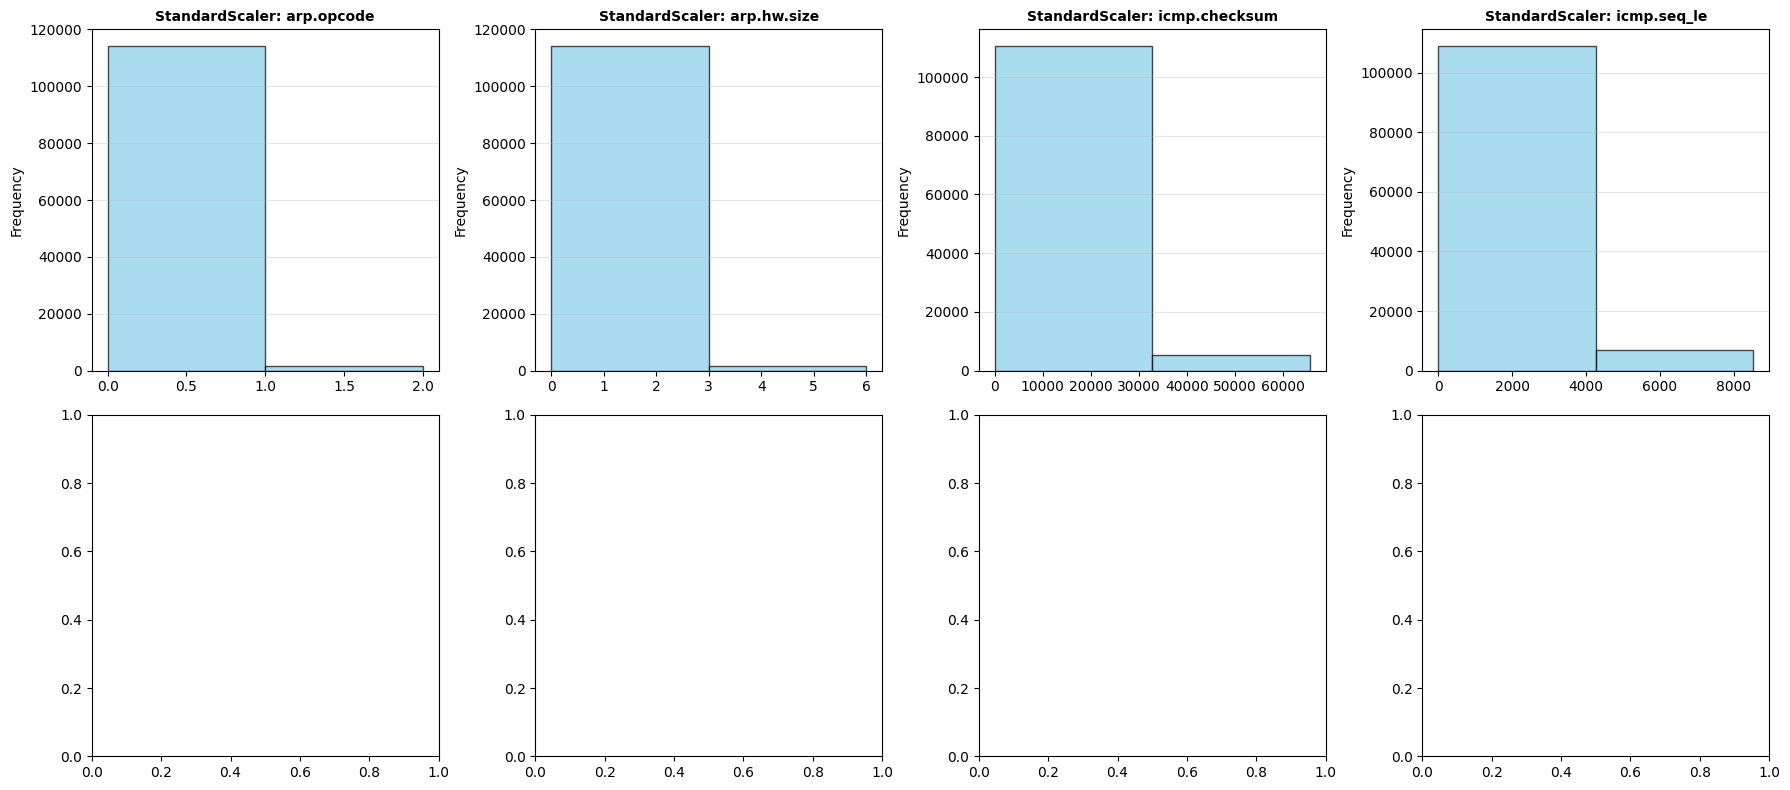

Feature Statistics Comparison:

StandardScaler (mean≈0, std≈1):
  Mean: 41668757.527765
  Std:  42783180.227296
  Min:  0.000000
  Max:  4294967019.000000

📌 Note: StandardScaler is used for LSTM (default)
   To use MinMaxScaler, replace 'df_combined' with 'df_scaled_minmax' in sequence creation


In [140]:
# Compare StandardScaler vs MinMaxScaler
print("=== Scaling Methods Comparison ===\n")

comparison_cols = feature_cols[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, col in enumerate(comparison_cols):
    # StandardScaler distributions
    axes[0, idx].hist(df_combined[col], bins=2, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'StandardScaler: {col}', fontsize=10, fontweight='bold')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(axis='y', alpha=0.3)
    


plt.tight_layout()
plt.show()

# Statistics comparison
print("Feature Statistics Comparison:\n")
print("StandardScaler (mean≈0, std≈1):")
print(f"  Mean: {df_combined[feature_cols].mean().mean():.6f}")
print(f"  Std:  {df_combined[feature_cols].std().mean():.6f}")
print(f"  Min:  {df_combined[feature_cols].min().min():.6f}")
print(f"  Max:  {df_combined[feature_cols].max().max():.6f}")


print("\n📌 Note: StandardScaler is used for LSTM (default)")
print("   To use MinMaxScaler, replace 'df_combined' with 'df_scaled_minmax' in sequence creation")

## Exploratory Data Analysis (EDA) 

=== Attack Type Distribution ===

Attack_type
Ransomware               10000
Password                 10000
Port_Scanning            10000
XSS                      10000
Backdoor                 10000
DDoS_TCP                 10000
Vulnerability_scanner    10000
SQL_injection            10000
Uploading                10000
DDoS_ICMP                10000
DDoS_HTTP                10000
Normal                    5000
OS_Fingerprinting         1001
Name: count, dtype: int64


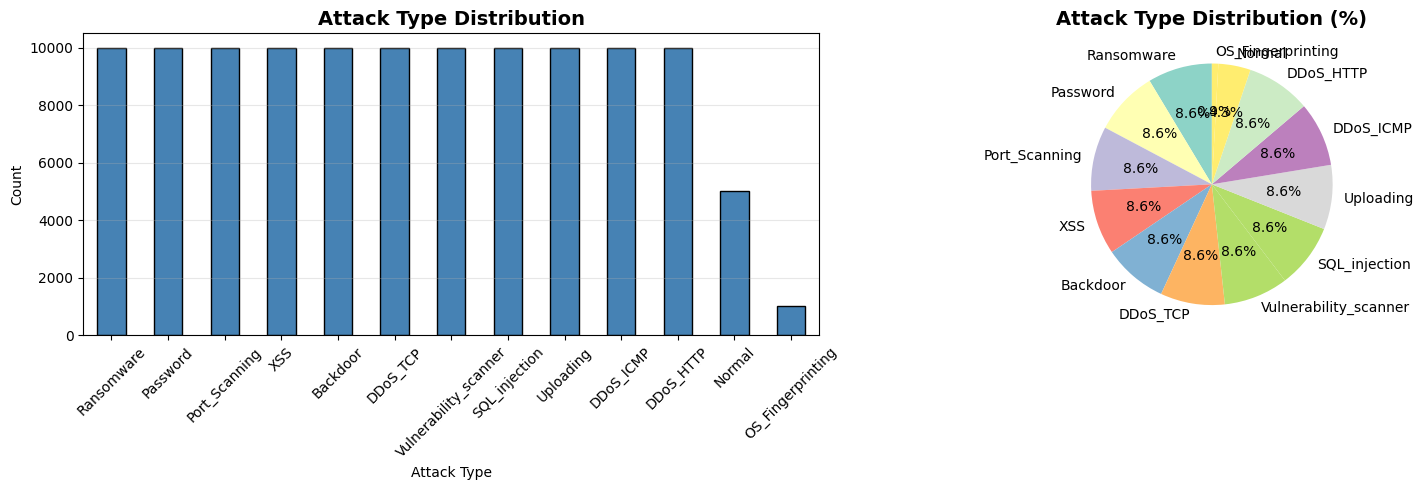


Total samples: 116001
Attack types: 13


In [141]:
# 1. Attack Type Distribution
print("=== Attack Type Distribution ===\n")
attack_counts = df_combined['Attack_type'].value_counts()
print(attack_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
attack_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(attack_counts)))
axes[1].pie(attack_counts.values, labels=attack_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attack Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal samples: {len(df_combined)}")
print(f"Attack types: {len(attack_counts)}")

=== Feature Statistics ===

Basic statistics of features:
                          count          mean           std  min          25%  \
arp.opcode             116001.0  1.979293e-02  1.733681e-01  0.0          0.0   
arp.hw.size            116001.0  8.679236e-02  7.163977e-01  0.0          0.0   
icmp.checksum          116001.0  3.002768e+03  1.107410e+04  0.0          0.0   
icmp.seq_le            116001.0  4.520811e+02  1.571136e+03  0.0          0.0   
http.content_length    116001.0  1.842184e+01  1.051525e+02  0.0          0.0   
http.response          116001.0  6.043913e-02  2.382997e-01  0.0          0.0   
tcp.ack                116001.0  9.022466e+07  3.479988e+08  0.0          1.0   
tcp.ack_raw            116001.0  1.492891e+09  1.249505e+09  0.0  250114459.0   
tcp.checksum           116001.0  2.876823e+04  2.063157e+04  0.0       9735.0   
tcp.connection.fin     116001.0  6.252532e-02  2.421083e-01  0.0          0.0   
tcp.connection.rst     116001.0  1.166197e-01  3.20

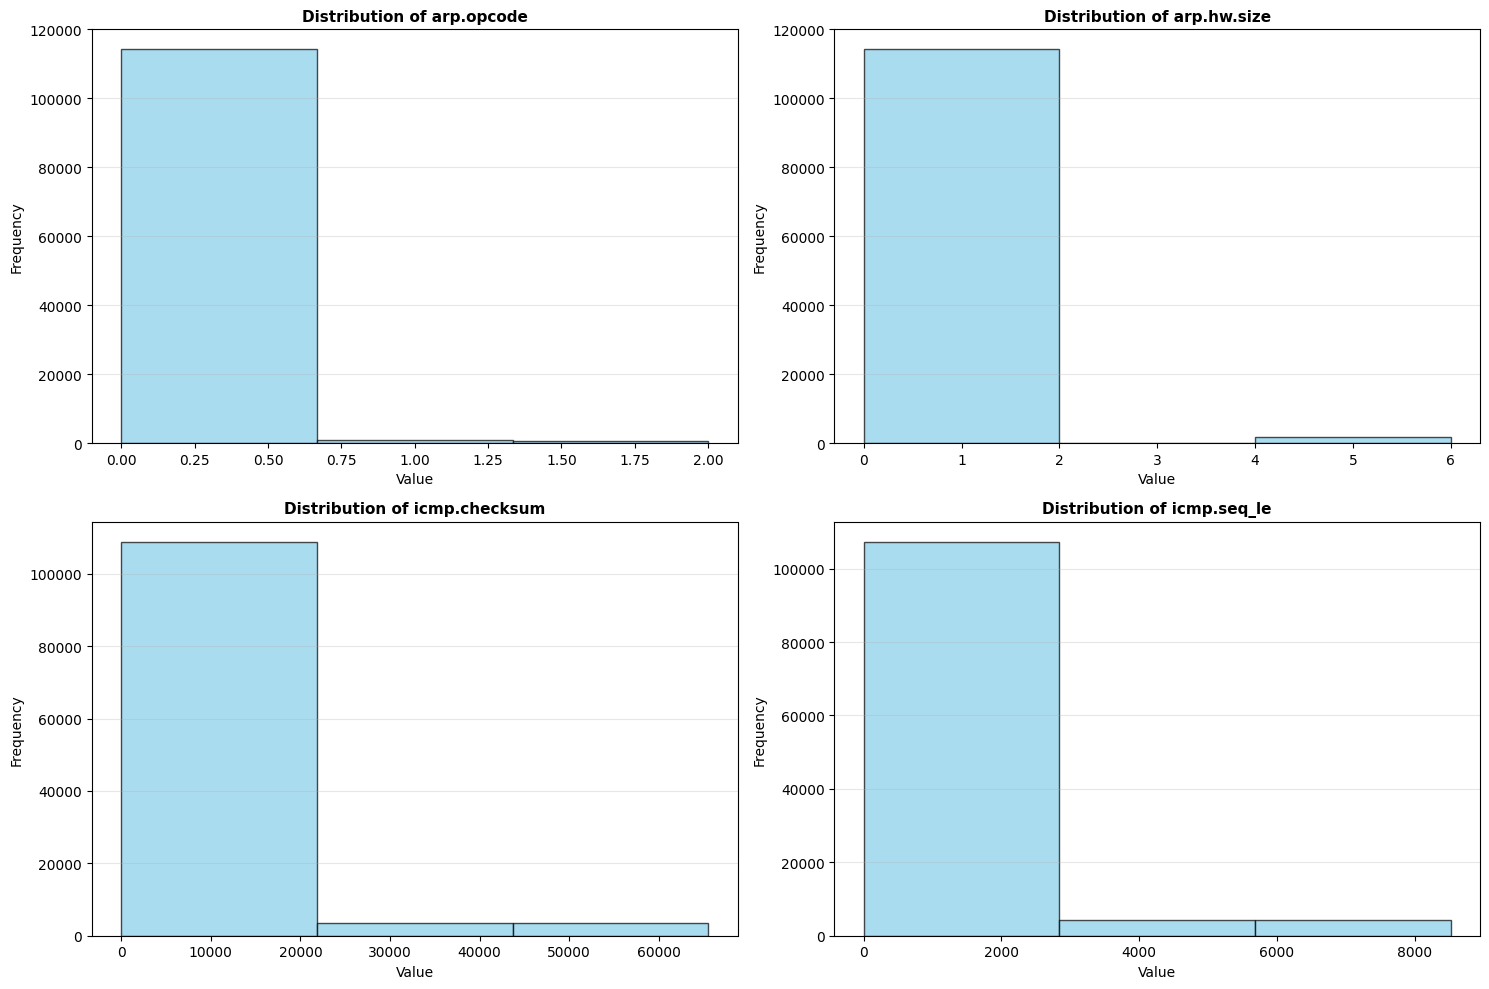


Total features (after encoding): 38


In [142]:
# 2. Feature Statistics
print("=== Feature Statistics ===\n")
print("Basic statistics of features:")
print(df_combined[feature_cols].describe().T.head(15))  # Show first 15 features

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of first 4 features
for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_combined[col], bins=3, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal features (after encoding): {len(feature_cols)}")

In [143]:
df_combined

,frame.time,ip.dst_host,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,http.content_length,http.response,tcp.ack,tcp.ack_raw,...,http.request.method_GET,http.request.method_OPTIONS,http.request.method_POST,http.request.method_PROPFIND,http.request.method_PUT,http.request.method_SEARCH,http.request.method_TRACE,mqtt.conack.flags_0.0,mqtt.conack.flags_0,mqtt.conack.flags_0x00000000
0,2021-01-01 00:00:06.541715,0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
1,2021-01-01 00:00:06.541747,0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
2,2021-01-01 00:00:43.783774,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
3,2021-01-01 00:00:44.790153,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
4,2021-01-01 00:00:48.318027,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115996,2021-01-01 23:17:49.989238,99.34.118.158,0.0,0.0,60131.0,5326.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
115997,2021-01-01 19:02:38.622301,99.46.221.104,0.0,0.0,0.0,0.0,0.0,0.0,121.0,2.069342e+09,...,False,False,False,False,False,False,False,True,False,False
115998,2021-01-01 23:17:49.519180,99.81.238.228,0.0,0.0,57833.0,3799.0,0.0,0.0,0.0,0.000000e+00,...,False,False,False,False,False,False,False,True,False,False
115999,2021-01-01 19:02:38.630631,99.90.226.202,0.0,0.0,0.0,0.0,0.0,0.0,121.0,3.456621e+08,...,False,False,False,False,False,False,False,True,False,False


=== Feature Correlation Analysis ===



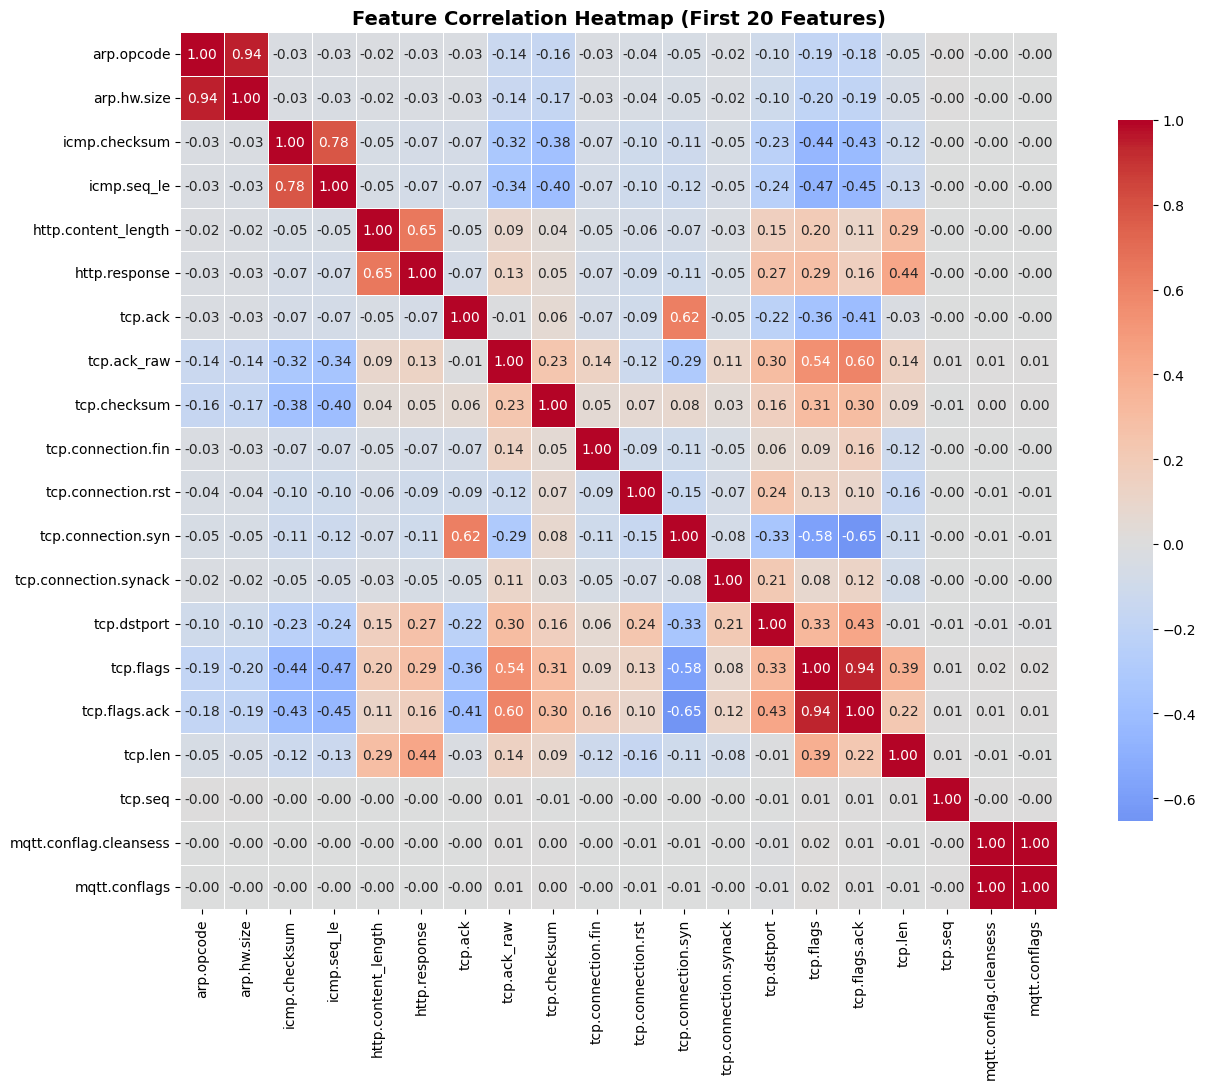

Top 10 feature correlations:
  1. mqtt.conflag.cleansess <-> mqtt.conflags: 1.0000
  2. arp.opcode <-> arp.hw.size: 0.9424
  3. tcp.flags <-> tcp.flags.ack: 0.9380
  4. icmp.checksum <-> icmp.seq_le: 0.7825
  5. tcp.connection.syn <-> tcp.flags.ack: 0.6537
  6. http.content_length <-> http.response: 0.6464
  7. tcp.ack <-> tcp.connection.syn: 0.6243
  8. tcp.ack_raw <-> tcp.flags.ack: 0.5990
  9. tcp.connection.syn <-> tcp.flags: 0.5795
  10. tcp.ack_raw <-> tcp.flags: 0.5433


In [144]:
# 3. Correlation Heatmap
print("=== Feature Correlation Analysis ===\n")

# Calculate correlation for first 20 features to avoid overcrowding
corr_cols = feature_cols[:20]
correlation_matrix = df_scaled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap (First 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highest correlations
print("Top 10 feature correlations:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], 
                          abs(correlation_matrix.iloc[i, j])))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for i, (feat1, feat2, corr) in enumerate(corr_pairs[:10]):
    print(f"  {i+1}. {feat1} <-> {feat2}: {corr:.4f}")

=== Feature Distribution by Attack Type ===



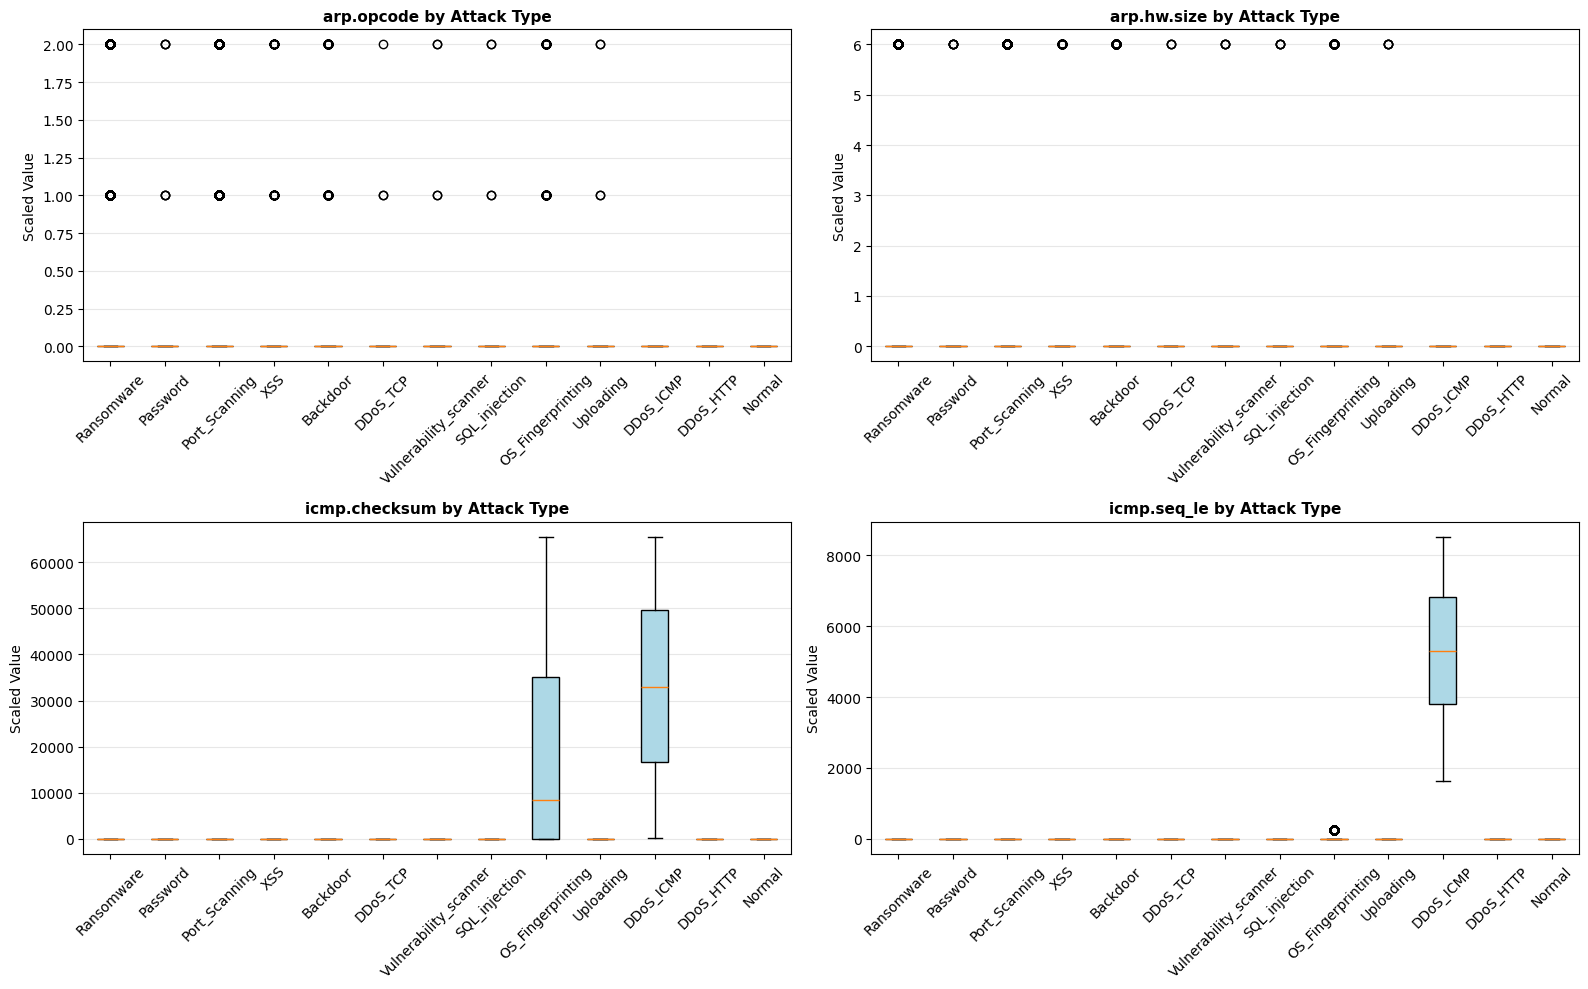

Box plots show feature distributions across different attack types


In [145]:
# 4. Attack Type Feature Comparison (Box plots)
print("=== Feature Distribution by Attack Type ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Select 4 features for comparison
compare_features = feature_cols[:4]

for idx, feature in enumerate(compare_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create box plot for each attack type
    data_for_plot = [df_combined[df_combined['Attack_type'] == attack][feature].values 
                     for attack in df_combined['Attack_type'].unique()]
    
    bp = ax.boxplot(data_for_plot, labels=df_combined['Attack_type'].unique(), patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_title(f'{feature} by Attack Type', fontsize=11, fontweight='bold')
    ax.set_ylabel('Scaled Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Box plots show feature distributions across different attack types")

=== Time Series Patterns ===



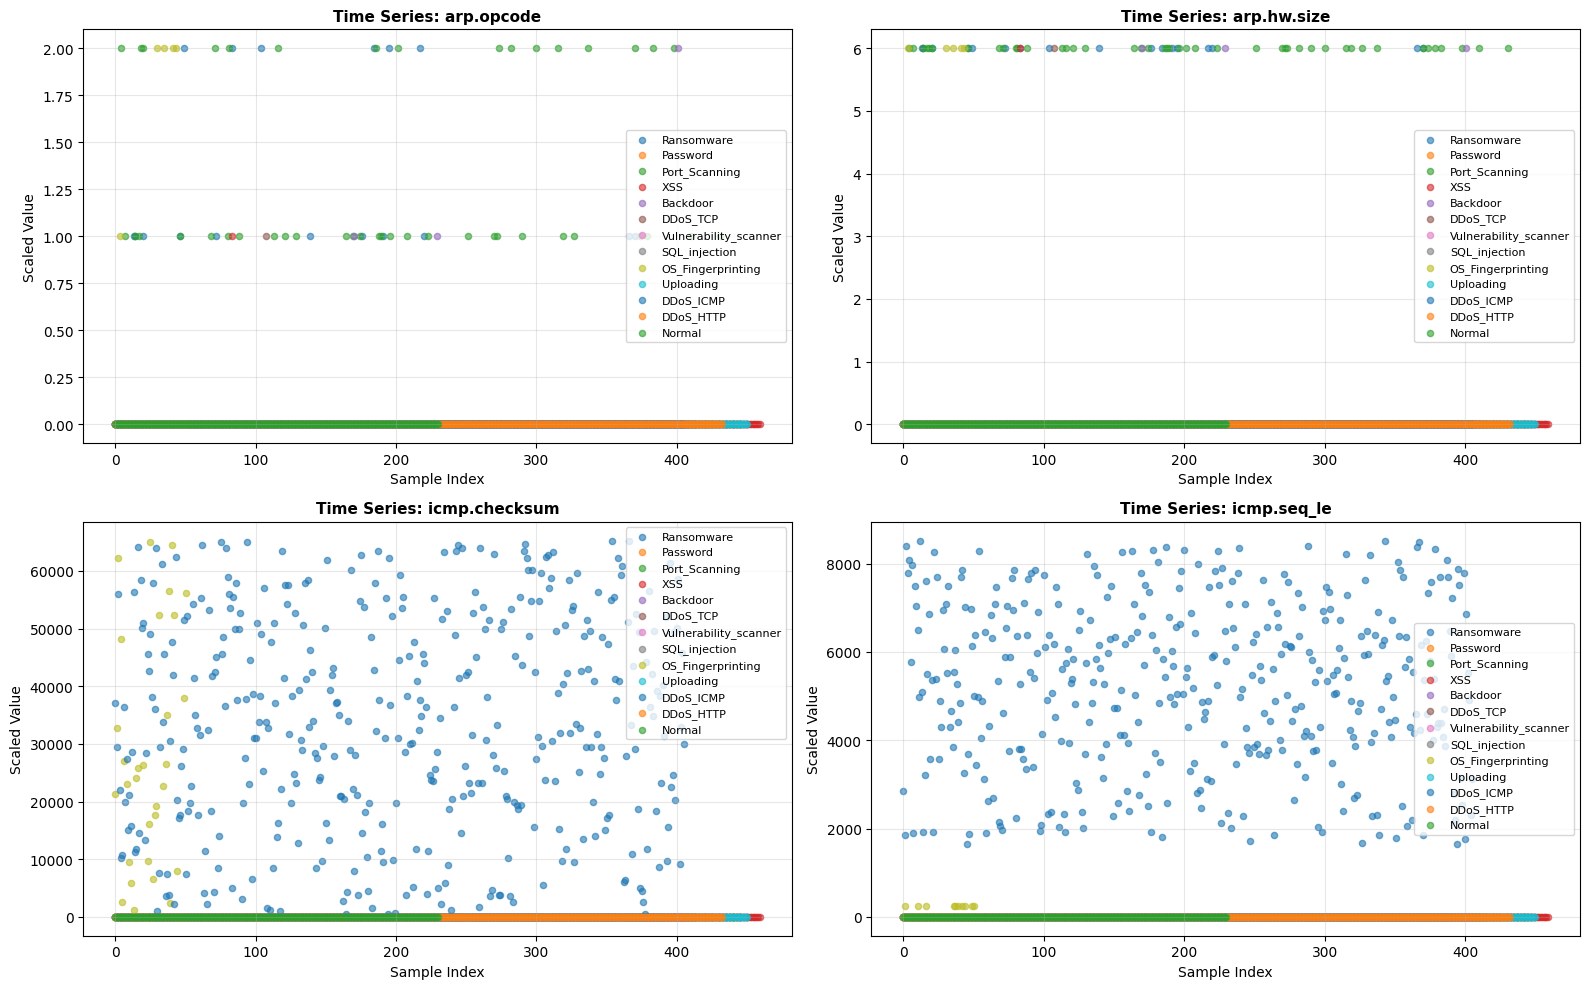

Time series patterns show how features vary across different attack types


In [146]:
# 5. Time Series Patterns - Feature values over time
print("=== Time Series Patterns ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot first feature values over time colored by attack type
for idx, feature in enumerate(feature_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # Sample data for visualization (to avoid overcrowding)
    sample_df = df_combined.sample(n=min(5000, len(df_combined)), random_state=42)
    
    # Plot scatter for each attack type
    for attack_type in df_combined['Attack_type'].unique():
        attack_data = sample_df[sample_df['Attack_type'] == attack_type]
        ax.scatter(range(len(attack_data)), attack_data[feature], 
                  label=attack_type, alpha=0.6, s=20)
    
    ax.set_title(f'Time Series: {feature}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Scaled Value')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series patterns show how features vary across different attack types")

=== Mean Feature Values by Attack Type ===



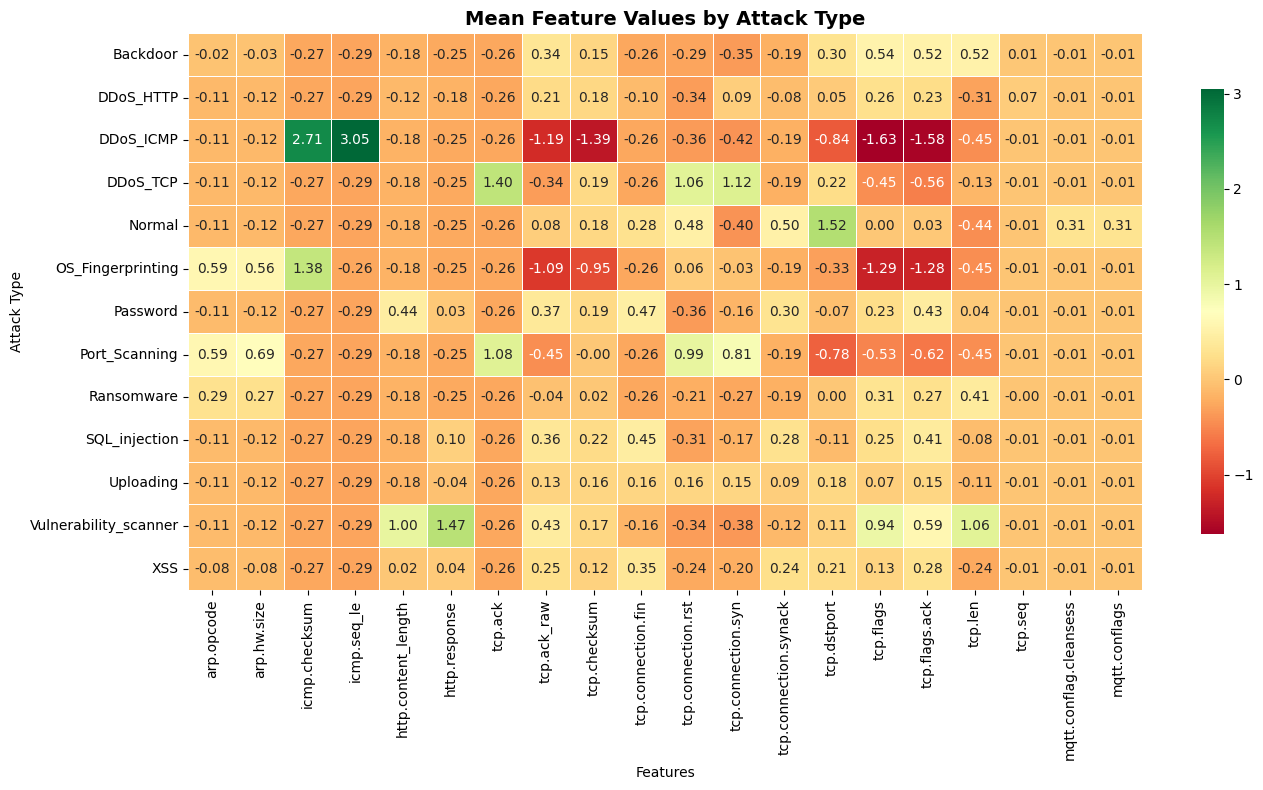


Mean values show characteristic patterns of each attack type


In [147]:
# 6. Attack Type Mean Features Heatmap
print("=== Mean Feature Values by Attack Type ===\n")

# Calculate mean features for each attack type (using first 20 features)
heatmap_features = feature_cols[:20]
mean_features = df_scaled.groupby('Attack_type')[heatmap_features].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(mean_features, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={"shrink": 0.8}, linewidths=0.5, ax=ax)
ax.set_title('Mean Feature Values by Attack Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Attack Type')
plt.tight_layout()
plt.show()

print("\nMean values show characteristic patterns of each attack type")

=== Source IP Analysis ===

IP and Packet Statistics by Attack Type:
                       Unique_IPs  Total_Packets
Attack_type                                     
Backdoor                        7          10000
DDoS_HTTP                       2          10000
DDoS_ICMP                    3115          10000
DDoS_TCP                     4581          10000
Normal                          2           5000
OS_Fingerprinting               6           1001
Password                        6          10000
Port_Scanning                   5          10000
Ransomware                      7          10000
SQL_injection                   3          10000
Uploading                       6          10000
Vulnerability_scanner           6          10000
XSS                             7          10000


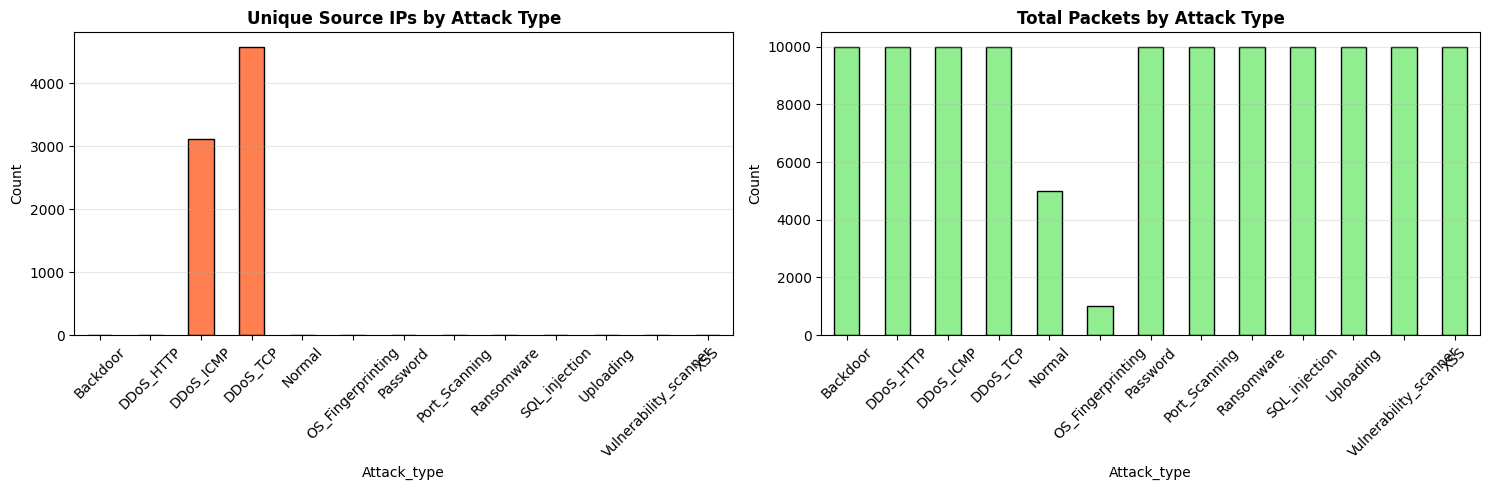


Top IPs per Attack Type:

Ransomware:
  192.168.0.170: 4475 packets
  192.168.0.128: 4385 packets
  0: 957 packets

Password:
  192.168.0.170: 5039 packets
  192.168.0.128: 4945 packets
  0: 13 packets

Port_Scanning:
  192.168.0.128: 4343 packets
  192.168.0.170: 4343 packets
  0: 1245 packets

XSS:
  192.168.0.128: 5047 packets
  192.168.0.170: 4447 packets
  0: 358 packets

Backdoor:
  192.168.0.170: 4936 packets
  192.168.0.128: 4755 packets
  0: 249 packets

DDoS_TCP:
  192.168.0.128: 5417 packets
  0: 4 packets
  1.1.253.80: 1 packets

Vulnerability_scanner:
  192.168.0.128: 4993 packets
  192.168.0.170: 4990 packets
  0: 14 packets

SQL_injection:
  192.168.0.128: 5117 packets
  192.168.0.170: 4879 packets
  0: 4 packets

OS_Fingerprinting:
  192.168.0.128: 467 packets
  192.168.0.170: 384 packets
  0: 132 packets

Uploading:
  192.168.0.128: 5440 packets
  192.168.0.170: 4535 packets
  0: 22 packets

DDoS_ICMP:
  192.168.0.128: 6886 packets
  0.11.152.209: 1 packets
  0.11.233

In [148]:
# 7. Source IP Analysis
print("=== Source IP Analysis ===\n")

# Group by attack type and get unique IPs and packet counts
ip_analysis = df_combined.groupby('Attack_type').agg({
    'ip.dst_host': 'nunique',
    'frame.time': 'count'
}).rename(columns={'ip.dst_host': 'Unique_IPs', 'frame.time': 'Total_Packets'})

print("IP and Packet Statistics by Attack Type:")
print(ip_analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Unique IPs per attack type
ip_analysis['Unique_IPs'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Unique Source IPs by Attack Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Packets per attack type
ip_analysis['Total_Packets'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Total Packets by Attack Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show top IPs per attack type
print("\nTop IPs per Attack Type:")
for attack_type in df_combined['Attack_type'].unique():
    attack_ips = df_combined[df_combined['Attack_type'] == attack_type]['ip.dst_host'].value_counts().head(3)
    print(f"\n{attack_type}:")
    for ip, count in attack_ips.items():
        print(f"  {ip}: {count} packets")

In [149]:
# 8. Data Summary & Insights
print("=== Data Summary & Key Insights ===\n")

print(f"Total Records: {len(df_combined):,}")
print(f"Total Unique IPs: {df_combined['ip.dst_host'].nunique()}")
print(f"Time Range: {df_combined['frame.time'].min()} to {df_combined['frame.time'].max()}")
print(f"Total Features: {len(feature_cols)}")
print(f"\nAttack Type Distribution:")
for attack, count in df_combined['Attack_type'].value_counts().items():
    pct = (count / len(df_combined)) * 100
    print(f"  • {attack:30s}: {count:6,} ({pct:5.1f}%)")

# Data quality metrics
print(f"\nData Quality:")
print(f"  • Missing values in frame.time: {df_combined['frame.time'].isna().sum()}")
print(f"  • Missing values in ip.dst_host: {df_combined['ip.dst_host'].isna().sum()}")
print(f"  • Duplicate rows: {df_combined.duplicated().sum()}")

# Feature statistics
print(f"\nFeature Statistics (scaled):")
print(f"  • Mean: {df_scaled[feature_cols].mean().mean():.4f}")
print(f"  • Std: {df_scaled[feature_cols].std().mean():.4f}")
print(f"  • Min: {df_scaled[feature_cols].min().min():.4f}")
print(f"  • Max: {df_scaled[feature_cols].max().max():.4f}")

=== Data Summary & Key Insights ===

Total Records: 116,001
Total Unique IPs: 7703
Time Range: 2021-01-01 00:00:01.163427 to 2021-01-01 23:59:59.358821
Total Features: 38

Attack Type Distribution:
  • Ransomware                    : 10,000 (  8.6%)
  • Password                      : 10,000 (  8.6%)
  • Port_Scanning                 : 10,000 (  8.6%)
  • XSS                           : 10,000 (  8.6%)
  • Backdoor                      : 10,000 (  8.6%)
  • DDoS_TCP                      : 10,000 (  8.6%)
  • Vulnerability_scanner         : 10,000 (  8.6%)
  • SQL_injection                 : 10,000 (  8.6%)
  • Uploading                     : 10,000 (  8.6%)
  • DDoS_ICMP                     : 10,000 (  8.6%)
  • DDoS_HTTP                     : 10,000 (  8.6%)
  • Normal                        :  5,000 (  4.3%)
  • OS_Fingerprinting             :  1,001 (  0.9%)

Data Quality:
  • Missing values in frame.time: 0
  • Missing values in ip.dst_host: 0
  • Duplicate rows: 0

Feature Statist

## 4. Prepare Data for ML Models (Shuffled)

In [150]:
# Use individual samples instead of sequences (no time series dependency)
print("Preparing data without time series sequences...\n")

# Use scaled features directly without grouping by IP
X_data = df_scaled[feature_cols].values
y_data = df_combined['Attack_type'].values

print(f"✓ Data prepared (individual samples, not sequences)")
print(f"  X shape: {X_data.shape} (samples, features)")
print(f"  y shape: {y_data.shape} (samples,)")
print(f"\nAttack type distribution:")
for attack_type, count in pd.Series(y_data).value_counts().items():
    print(f"  • {attack_type}: {count} samples")

Preparing data without time series sequences...

✓ Data prepared (individual samples, not sequences)
  X shape: (116001, 38) (samples, features)
  y shape: (116001,) (samples,)

Attack type distribution:
  • Ransomware: 10000 samples
  • Password: 10000 samples
  • Port_Scanning: 10000 samples
  • XSS: 10000 samples
  • Backdoor: 10000 samples
  • DDoS_TCP: 10000 samples
  • Vulnerability_scanner: 10000 samples
  • SQL_injection: 10000 samples
  • Uploading: 10000 samples
  • DDoS_ICMP: 10000 samples
  • DDoS_HTTP: 10000 samples
  • Normal: 5000 samples
  • OS_Fingerprinting: 1001 samples


## 5. Split Data for Model Training

In [151]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

print("Encoding and shuffling data...\n")

# Encode attack types
le = LabelEncoder()
y_encoded = le.fit_transform(y_data)
num_classes = len(le.classes_)

print(f"Number of attack classes: {num_classes}")
print(f"\nClass mapping:")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}")

# Shuffle the data
X_shuffled, y_shuffled = shuffle(X_data, y_encoded, random_state=42)

print(f"\n✓ Data shuffled")
print(f"  X shape: {X_shuffled.shape}")
print(f"  y shape: {y_shuffled.shape}")
print(f"\nLabel distribution after shuffling:")
for idx, label in enumerate(le.classes_):
    count = (y_shuffled == idx).sum()
    print(f"  {label}: {count} samples")

Encoding and shuffling data...

Number of attack classes: 13

Class mapping:
  0: Backdoor
  1: DDoS_HTTP
  2: DDoS_ICMP
  3: DDoS_TCP
  4: Normal
  5: OS_Fingerprinting
  6: Password
  7: Port_Scanning
  8: Ransomware
  9: SQL_injection
  10: Uploading
  11: Vulnerability_scanner
  12: XSS

✓ Data shuffled
  X shape: (116001, 38)
  y shape: (116001,)

Label distribution after shuffling:
  Backdoor: 10000 samples
  DDoS_HTTP: 10000 samples
  DDoS_ICMP: 10000 samples
  DDoS_TCP: 10000 samples
  Normal: 5000 samples
  OS_Fingerprinting: 1001 samples
  Password: 10000 samples
  Port_Scanning: 10000 samples
  Ransomware: 10000 samples
  SQL_injection: 10000 samples
  Uploading: 10000 samples
  Vulnerability_scanner: 10000 samples
  XSS: 10000 samples


In [152]:
# Split shuffled data into train and test sets (80-20 split)
print("Splitting shuffled data into train and test sets...\n")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_shuffled, y_shuffled, test_size=0.2, random_state=42, stratify=y_shuffled
)

print(f"Train set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set:  X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nTrain-Test Split Ratio: {len(X_train)} / {len(X_test)}")
print(f"\nClass distribution in train set:")
for idx, label in enumerate(le.classes_):
    count = (y_train == idx).sum()
    pct = (count / len(y_train)) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")
print(f"\nClass distribution in test set:")
for idx, label in enumerate(le.classes_):
    count = (y_test == idx).sum()
    pct = (count / len(y_test)) * 100
    print(f"  {label}: {count} ({pct:.1f}%)")

Splitting shuffled data into train and test sets...

Train set: X_train (92800, 38), y_train (92800,)
Test set:  X_test (23201, 38), y_test (23201,)

Train-Test Split Ratio: 92800 / 23201

Class distribution in train set:
  Backdoor: 8000 (8.6%)
  DDoS_HTTP: 8000 (8.6%)
  DDoS_ICMP: 8000 (8.6%)
  DDoS_TCP: 8000 (8.6%)
  Normal: 4000 (4.3%)
  OS_Fingerprinting: 800 (0.9%)
  Password: 8000 (8.6%)
  Port_Scanning: 8000 (8.6%)
  Ransomware: 8000 (8.6%)
  SQL_injection: 8000 (8.6%)
  Uploading: 8000 (8.6%)
  Vulnerability_scanner: 8000 (8.6%)
  XSS: 8000 (8.6%)

Class distribution in test set:
  Backdoor: 2000 (8.6%)
  DDoS_HTTP: 2000 (8.6%)
  DDoS_ICMP: 2000 (8.6%)
  DDoS_TCP: 2000 (8.6%)
  Normal: 1000 (4.3%)
  OS_Fingerprinting: 201 (0.9%)
  Password: 2000 (8.6%)
  Port_Scanning: 2000 (8.6%)
  Ransomware: 2000 (8.6%)
  SQL_injection: 2000 (8.6%)
  Uploading: 2000 (8.6%)
  Vulnerability_scanner: 2000 (8.6%)
  XSS: 2000 (8.6%)


## 6. Build and Train ML Models

In [153]:
# Build and train XGBoost model
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Building and training XGBoost model...\n")

# Create XGBoost classifier
model = xgb.XGBClassifier(
    objective='multi:softmax',  
    num_class=num_classes,
    max_depth=8,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    eval_metric='mlogloss'
)

print("Model Hyperparameters:")
print(f"  • n_estimators: {model.n_estimators}")
print(f"  • max_depth: {model.max_depth}")
print(f"  • learning_rate: {model.learning_rate}")
print(f"  • subsample: {model.subsample}")
print(f"  • colsample_bytree: {model.colsample_bytree}")

print("\n" + "="*60)
print("Training XGBoost model...")
print("="*60)

# Train with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    # early_stopping_rounds=10,
    verbose=False
)

print("\n✓ Model training completed")
# print(f"Best iteration: {model.best_iteration}")

Building and training XGBoost model...

Model Hyperparameters:
  • n_estimators: 200
  • max_depth: 8
  • learning_rate: 0.1
  • subsample: 0.8
  • colsample_bytree: 0.8

Training XGBoost model...

✓ Model training completed


Analyzing feature importance...

Top 20 Most Important Features:
   1. Feature   20: 0.189794
   2. Feature   35: 0.182785
   3. Feature    3: 0.119653
   4. Feature   36: 0.089530
   5. Feature    4: 0.079413
   6. Feature   26: 0.068931
   7. Feature   27: 0.052647
   8. Feature   10: 0.028097
   9. Feature    6: 0.028040
  10. Feature   30: 0.025534
  11. Feature   16: 0.020599
  12. Feature   28: 0.020257
  13. Feature   17: 0.018500
  14. Feature   13: 0.014143
  15. Feature   34: 0.013458
  16. Feature    2: 0.012200
  17. Feature    5: 0.008374
  18. Feature   14: 0.006827
  19. Feature   11: 0.004747
  20. Feature   12: 0.004124


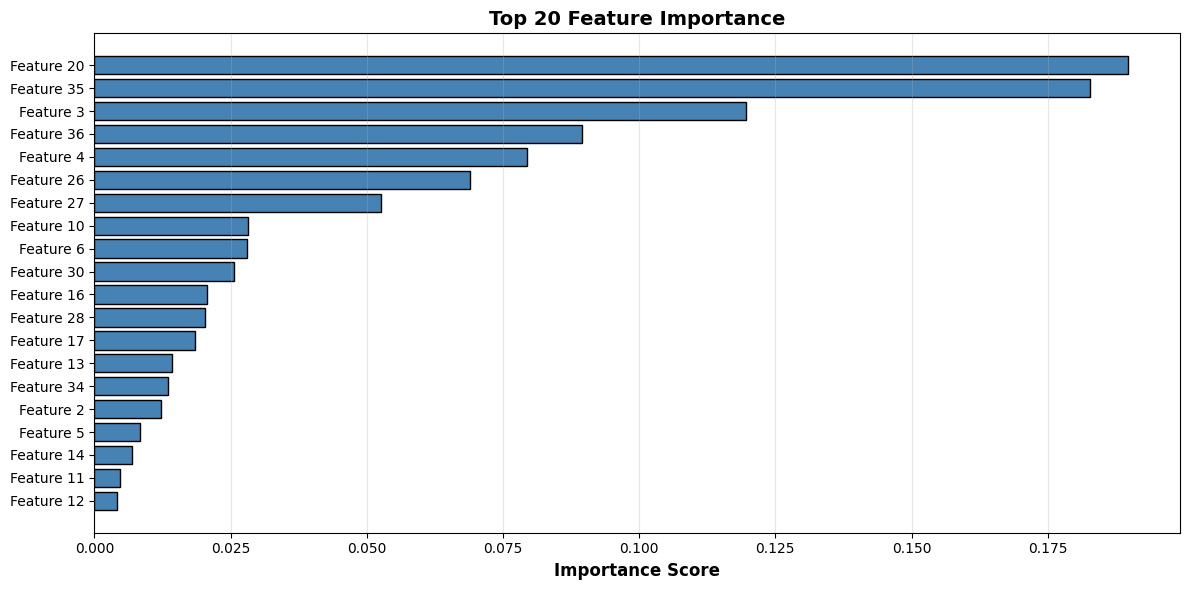

In [154]:
# Feature Importance Analysis
print("Analyzing feature importance...\n")

# Get feature importance
importance = model.feature_importances_
feature_names = [f"feature_{i}" for i in range(len(importance))]

# Sort by importance
indices = np.argsort(importance)[::-1]

print("Top 20 Most Important Features:")
for i in range(min(20, len(indices))):
    print(f"  {i+1:2d}. Feature {indices[i]:4d}: {importance[indices[i]]:.6f}")

# Plot top 20 important features
fig, ax = plt.subplots(figsize=(12, 6))
top_indices = indices[:20]
ax.barh(range(len(top_indices)), importance[top_indices], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([f"Feature {i}" for i in top_indices])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [155]:
# Model Predictions
print("Making predictions on test set...\n")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")
print("\n✓ Predictions completed")

Making predictions on test set...

Predictions shape: (23201,)
Prediction probabilities shape: (23201, 13)

✓ Predictions completed


## 7. Model Evaluation

In [156]:
print("=== XGBoost Model Evaluation ===\n")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
# print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

=== XGBoost Model Evaluation ===

Test Accuracy: 0.9271 (92.71%)

Classification Report:

Confusion Matrix:
[[1907    0    0    0    0    1    0   20   72    0    0    0    0]
 [   0 1922    0    0    0    0   27    0    0   24    0    0   27]
 [   0    0 2000    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0 2000    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0 1000    0    0    0    0    0    0    0    0]
 [   1    0    2    0    0  153    0   25   20    0    0    0    0]
 [   0  159    0    0    0    0 1681    0    0  115    7    0   38]
 [   0    0    0    0    0    8    0 1915   77    0    0    0    0]
 [  19    0    0    0    0    1    0   84 1896    0    0    0    0]
 [   0  167    0    0    0    0  135    0    0 1643   10    4   41]
 [   0  102    0    0    0    0   35    0    0   37 1764    0   62]
 [   0   16    0    0    0    0    4    0    0   19    2 1952    7]
 [   0  125    0    0    0    0   53    0    0   58   88    0 1676]]


Creating confusion matrix visualization...

[[1907    0    0    0    0    1    0   20   72    0    0    0    0]
 [   0 1922    0    0    0    0   27    0    0   24    0    0   27]
 [   0    0 2000    0    0    0    0    0    0    0    0    0    0]
 [   0    0    0 2000    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0 1000    0    0    0    0    0    0    0    0]
 [   1    0    2    0    0  153    0   25   20    0    0    0    0]
 [   0  159    0    0    0    0 1681    0    0  115    7    0   38]
 [   0    0    0    0    0    8    0 1915   77    0    0    0    0]
 [  19    0    0    0    0    1    0   84 1896    0    0    0    0]
 [   0  167    0    0    0    0  135    0    0 1643   10    4   41]
 [   0  102    0    0    0    0   35    0    0   37 1764    0   62]
 [   0   16    0    0    0    0    4    0    0   19    2 1952    7]
 [   0  125    0    0    0    0   53    0    0   58   88    0 1676]]


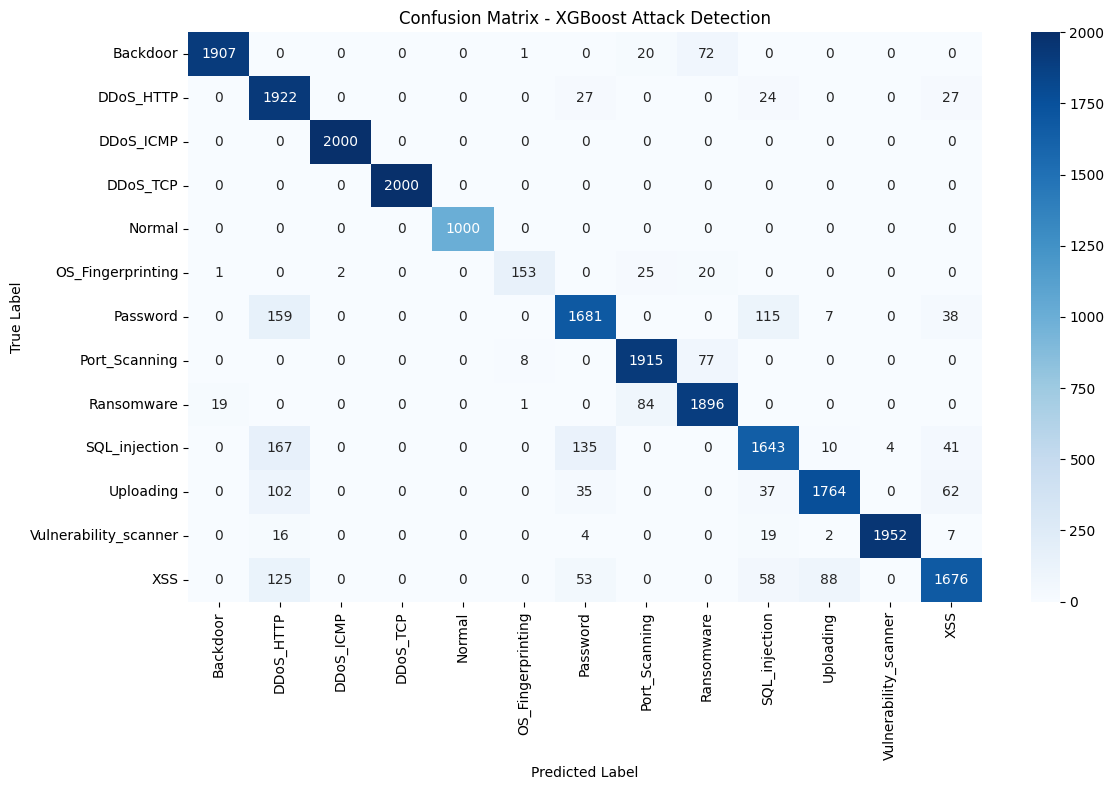

In [157]:
# Confusion Matrix Visualization
print("Creating confusion matrix visualization...\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost Attack Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [158]:
from sklearn.metrics import precision_score, recall_score, classification_report

# For multiclass → use 'weighted' or 'macro'
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9302271755711418
Recall: 0.9270721089608207


## 8. Plot Model Learning Curve

Plotting XGBoost evaluation results...

Training and Validation Performance:
  Train Accuracy: 0.9482
  Validation Accuracy: 0.9271


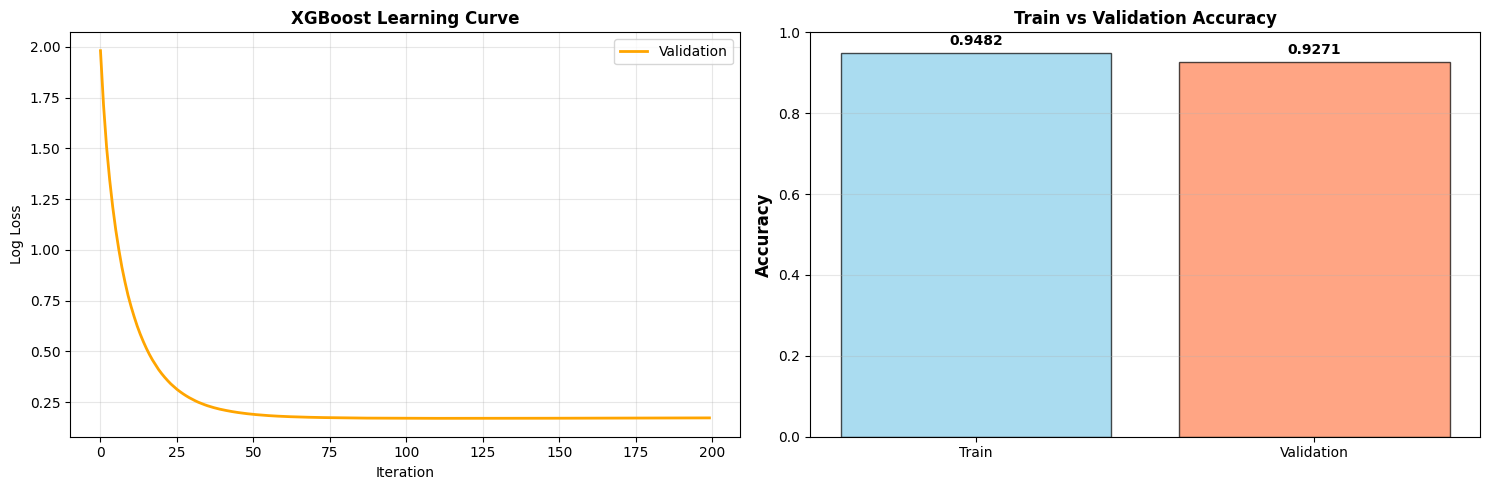

In [159]:
# Plot XGBoost evaluation metrics
print("Plotting XGBoost evaluation results...\n")

# Get evaluation results
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Get metric names
metric_names = list(results.keys())

if metric_names:
    for metric_name in metric_names:
        metrics = results[metric_name]
        
        # Plot training and validation metrics
        ax = axes[0] if metric_name == 'validation_0' else axes[1]
        
        if 'validation_0' in results:
            ax.plot(results['validation_0'][list(results['validation_0'].keys())[0]], 
                   label='Validation', color='orange', linewidth=2)
        
        ax.set_title(f'XGBoost Learning Curve', fontsize=12, fontweight='bold')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Log Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        break

# Alternative: Show training and validation accuracy
print("Training and Validation Performance:")
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_test, y_pred)

print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Validation Accuracy: {val_acc:.4f}")

# Plot comparison
ax = axes[1] if len(metric_names) > 0 else axes[0]
categories = ['Train', 'Validation']
accuracies = [train_acc, val_acc]
colors_bar = ['skyblue', 'coral']

ax.bar(categories, accuracies, color=colors_bar, edgecolor='black', alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Train vs Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Save XGBoost Model

In [161]:
# Save model and artifacts
import pickle
import json

print("Saving XGBoost model and artifacts...\n")

# Save XGBoost model (JSON format for better portability)
model.save_model('xgboost_attack_detection_model.json')
print("✓ XGBoost model saved as 'xgboost_attack_detection_model.json'")

# Also save as pickle
with open('xgboost_attack_detection_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✓ XGBoost model saved as 'xgboost_attack_detection_model.pkl'")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ StandardScaler saved as 'scaler.pkl'")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder saved as 'label_encoder.pkl'")

# Save model information
model_info = {
    'model_type': 'XGBoost',
    'num_classes': num_classes,
    'class_names': le.classes_.tolist(),
    'n_features': X_train.shape[1],
    'test_accuracy': float(accuracy_score(y_test, y_pred)),
    'train_accuracy': float(accuracy_score(y_train, model.predict(X_train)))
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print("✓ Model info saved as 'model_info.json'")

print("\n" + "="*60)
print("✓ All artifacts saved successfully!")
print("="*60)
print("\nModel Summary:")
print(f"  • Algorithm: XGBoost")
print(f"  • Classes: {num_classes}")
print(f"  • Features: {X_train.shape[1]}")
print(f"  • Train Accuracy: {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"  • Test Accuracy: {accuracy:.4f}")

Saving XGBoost model and artifacts...

✓ XGBoost model saved as 'xgboost_attack_detection_model.json'
✓ XGBoost model saved as 'xgboost_attack_detection_model.pkl'
✓ StandardScaler saved as 'scaler.pkl'
✓ Label encoder saved as 'label_encoder.pkl'
✓ Model info saved as 'model_info.json'

✓ All artifacts saved successfully!

Model Summary:
  • Algorithm: XGBoost
  • Classes: 13
  • Features: 38
  • Train Accuracy: 0.9482
  • Test Accuracy: 0.9271
